# 📊 Evaluation — Diabetes Classification

Notebook ini berisi evaluasi lengkap dari 4 model Machine Learning:
- Random Forest
- SVM (Support Vector Machine)
- Logistic Regression
- KNN (K-Nearest Neighbors)

**Dataset:** Pima Indians Diabetes Dataset  
**Target:** `Outcome` — 0 (tidak diabetes), 1 (diabetes)

## 1. Import Library & Load Data

In [27]:
# Library standar untuk evaluasi ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & split
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Metrics evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

print('Semua library berhasil di-import!')

Semua library berhasil di-import!


In [28]:
# Load dataset yang sudah dibersihkan oleh tim
df = pd.read_csv('data/cleaned_data.csv')

print(f'Shape dataset: {df.shape}')
print(f'\nDistribusi label (Outcome):')
print(df['Outcome'].value_counts())
print(f'\n0 = tidak diabetes, 1 = diabetes')

Shape dataset: (768, 10)

Distribusi label (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

0 = tidak diabetes, 1 = diabetes


## 2. Persiapan Data (Train/Test Split)

> **Catatan penting:** Di `model.ipynb` ditemukan *data leakage* — kolom `Outcome` (target) ikut masuk sebagai fitur X saat training, sehingga akurasi menjadi 100% (tidak valid). Di notebook ini kita perbaiki dengan membuang `Outcome` dan `Glucose_bin` dari fitur X.

In [29]:
# Fitur (X) = semua kolom KECUALI target dan Glucose_bin
X = df.drop(['Outcome', 'Glucose_bin'], axis=1)
y = df['Outcome']

# Split 80% train, 20% test — random_state=42 supaya hasilnya reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_impute:
    X_train[col] = X_train[col].replace(0, np.nan)
    X_test[col] = X_test[col].replace(0, np.nan)
    
    median_val = X_train[col].median()
    
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Scaling — dibutuhkan SVM, LR, dan KNN (Random Forest tidak perlu)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit hanya di train!
X_test_scaled  = scaler.transform(X_test)         # test hanya di-transform

print(f'Training set : {X_train.shape[0]} data')
print(f'Testing set  : {X_test.shape[0]} data')
print(f'Fitur yang digunakan: {X.columns.tolist()}')

Training set : 614 data
Testing set  : 154 data
Fitur yang digunakan: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 3. Training Ulang Model

Model di-training ulang dengan data yang benar (tanpa data leakage). Parameter tetap sama seperti di `model.ipynb`.

In [30]:
# Inisialisasi model — parameter sama seperti model.ipynb
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', probability=True, random_state=42)
lr  = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# RF pakai data TIDAK di-scale (tree-based tidak perlu scaling)
# SVM, LR, KNN pakai data yang sudah di-scale
rf.fit(X_train, y_train)
svm.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

print('Semua model selesai di-training!')

Semua model selesai di-training!


## 4. Prediksi

In [31]:
# Prediksi kelas (0 atau 1)
y_pred_rf  = rf.predict(X_test)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_lr  = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

# Prediksi probabilitas — dibutuhkan untuk ROC curve & AUC
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print('Prediksi selesai!')
print(f'Contoh 10 prediksi RF : {y_pred_rf[:10].tolist()}')
print(f'Label aslinya         : {y_test.values[:10].tolist()}')

Prediksi selesai!
Contoh 10 prediksi RF : [1, 0, 0, 0, 1, 1, 0, 1, 1, 1]
Label aslinya         : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 5. Metrics Evaluasi

| Metric | Arti |
|---|---|
| **Accuracy** | Berapa % prediksi yang benar dari total data |
| **Precision** | Dari semua yang diprediksi diabetes, berapa yang benar-benar diabetes |
| **Recall** | Dari semua yang benar-benar diabetes, berapa yang berhasil terdeteksi |
| **F1-Score** | Rata-rata harmonis Precision & Recall |
| **AUC-ROC** | Seberapa baik model membedakan kelas 0 vs 1 (0.5 = random, 1.0 = sempurna) |

In [32]:
def get_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'F1-Score' : round(f1_score(y_true, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

results = pd.DataFrame([
    get_metrics('Random Forest',       y_test, y_pred_rf,  y_prob_rf),
    get_metrics('SVM',                 y_test, y_pred_svm, y_prob_svm),
    get_metrics('Logistic Regression', y_test, y_pred_lr,  y_prob_lr),
    get_metrics('KNN',                 y_test, y_pred_knn, y_prob_knn),
])

results.set_index('Model', inplace=True)
print('=== Tabel Perbandingan Metrics Semua Model ===')
results

=== Tabel Perbandingan Metrics Semua Model ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Random Forest,0.7468,0.6379,0.6727,0.6549,0.8340
SVM,0.7468,0.6667,0.5818,0.6214,0.8086
Logistic Regression,0.7532,0.6667,0.6182,0.6415,0.8228
KNN,0.7208,0.5968,0.6727,0.6325,0.7628


## 6. Visualisasi — Perbandingan Metrics

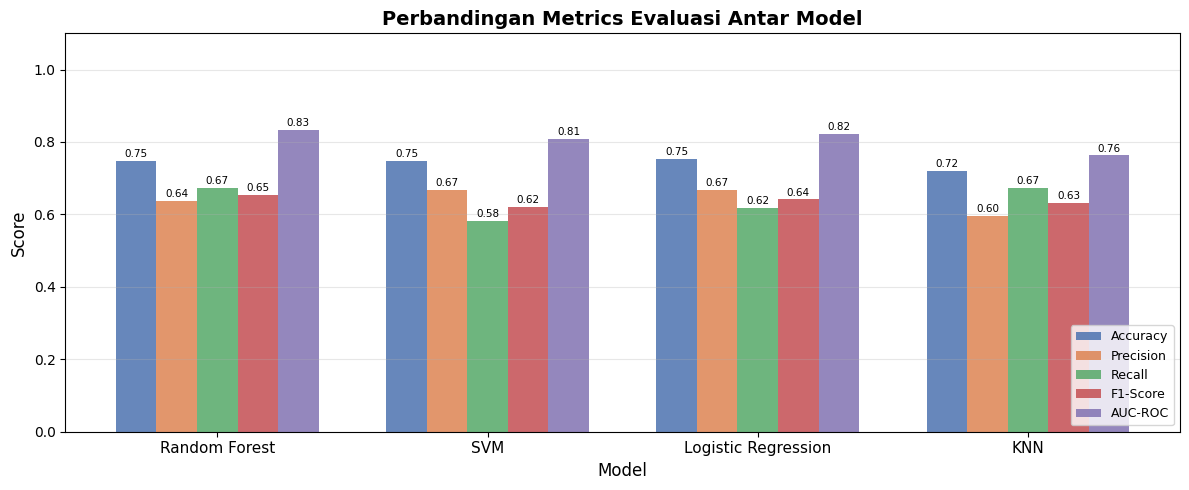

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(results.index))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

for i, (metric, color) in enumerate(zip(metrics_cols, colors)):
    bars = ax.bar(x + i * width, results[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Metrics Evaluasi Antar Model', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results.index, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot/eval_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrix

Confusion Matrix menunjukkan detail prediksi model:
- **True Positive (TP):** Diprediksi diabetes, dan memang diabetes ✅
- **True Negative (TN):** Diprediksi tidak diabetes, dan memang tidak ✅
- **False Positive (FP):** Diprediksi diabetes, padahal tidak ❌ *(Type I Error)*
- **False Negative (FN):** Diprediksi tidak diabetes, padahal diabetes ❌ *(Type II Error — berbahaya di konteks medis!)*

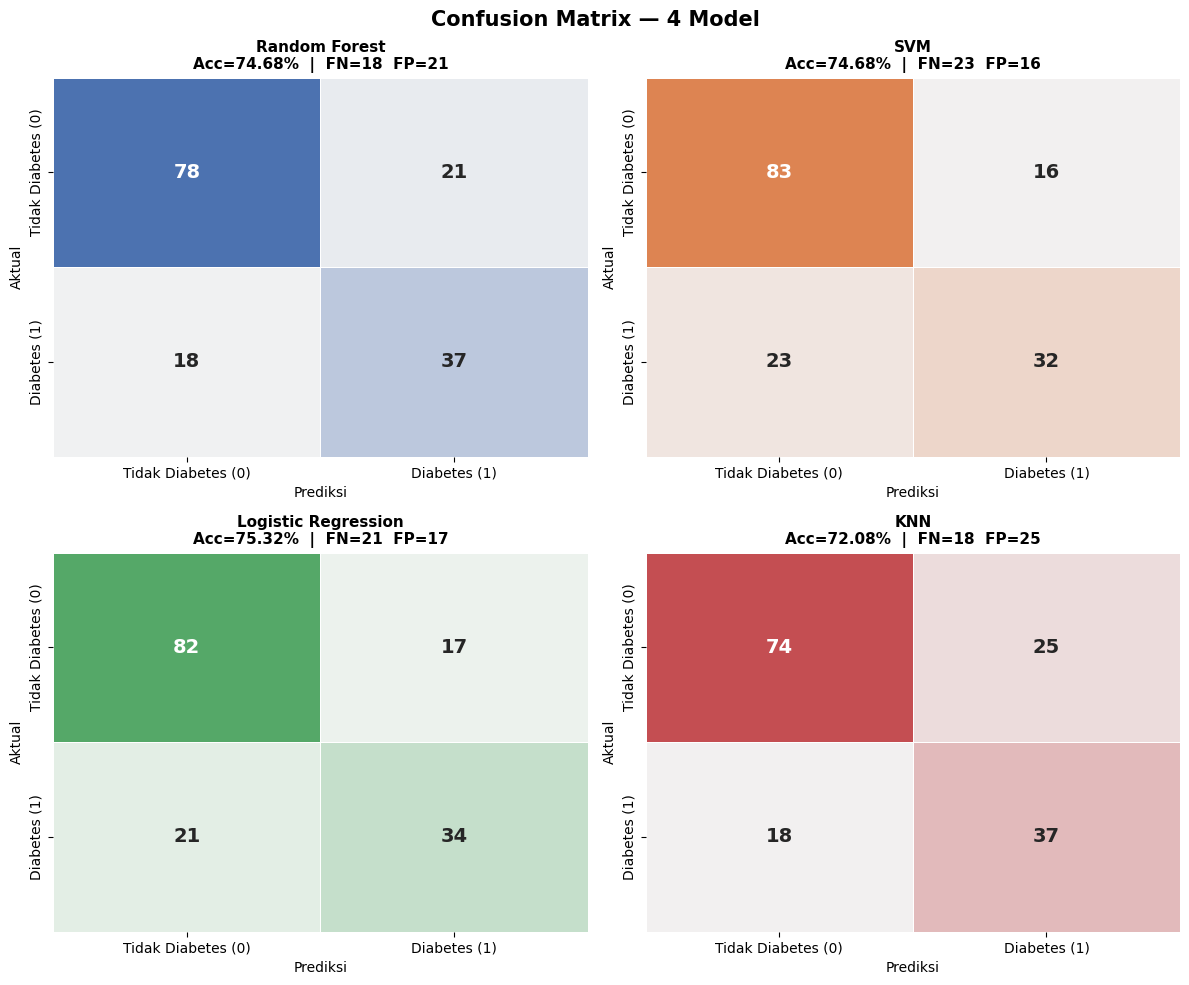

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrix — 4 Model', fontsize=15, fontweight='bold')

models_info = [
    ('Random Forest',       y_pred_rf,  '#4C72B0'),
    ('SVM',                 y_pred_svm, '#DD8452'),
    ('Logistic Regression', y_pred_lr,  '#55A868'),
    ('KNN',                 y_pred_knn, '#C44E52'),
]

for ax, (name, y_pred, color) in zip(axes.flat, models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=['Tidak Diabetes (0)', 'Diabetes (1)'],
        yticklabels=['Tidak Diabetes (0)', 'Diabetes (1)'],
        ax=ax, linewidths=0.5, cbar=False,
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name}\nAcc={accuracy_score(y_test,y_pred):.2%}  |  FN={fn}  FP={fp}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)

plt.tight_layout()
plt.savefig('plot/eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. ROC Curve & AUC

ROC Curve menggambarkan trade-off antara **True Positive Rate (Recall)** vs **False Positive Rate**.  
Semakin kurva mendekati pojok kiri atas = semakin baik model.  
**AUC > 0.8** = kemampuan diskriminasi yang baik.

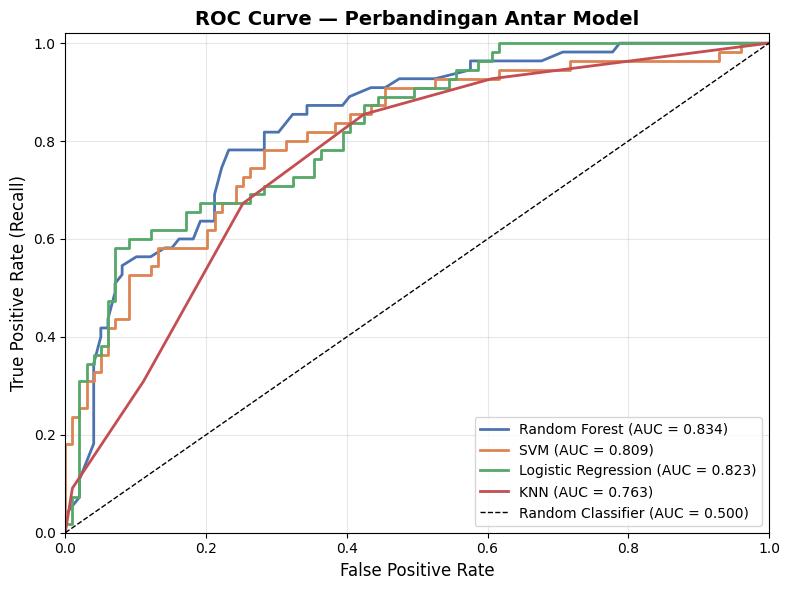

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

models_roc = [
    ('Random Forest',       y_prob_rf,  '#4C72B0'),
    ('SVM',                 y_prob_svm, '#DD8452'),
    ('Logistic Regression', y_prob_lr,  '#55A868'),
    ('KNN',                 y_prob_knn, '#C44E52'),
]

for name, y_prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

# Garis baseline = model random
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Perbandingan Antar Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plot/eval_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cross-Validation

Cross-Validation (5-Fold) mengukur **stabilitas** model — bukan hanya dari satu split, tapi rata-rata dari 5 split berbeda.

> CV score ≈ test score → model tidak overfitting

In [36]:
# Bungkus dalam Pipeline supaya scaling tidak leak ke data validasi CV
cv_models = {
    'Random Forest'      : Pipeline([('model', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'SVM'                : Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', probability=True, random_state=42))]),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'KNN'                : Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
}

print(f'{"Model":<25} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 62)

cv_results = {}
for name, pipeline in cv_models.items():
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}')

Model                         Mean      Std      Min      Max
--------------------------------------------------------------
Random Forest               0.7644   0.0342   0.7403   0.8301
SVM                         0.7527   0.0244   0.7273   0.7974
Logistic Regression         0.7722   0.0180   0.7468   0.7974
KNN                         0.7357   0.0241   0.6948   0.7647


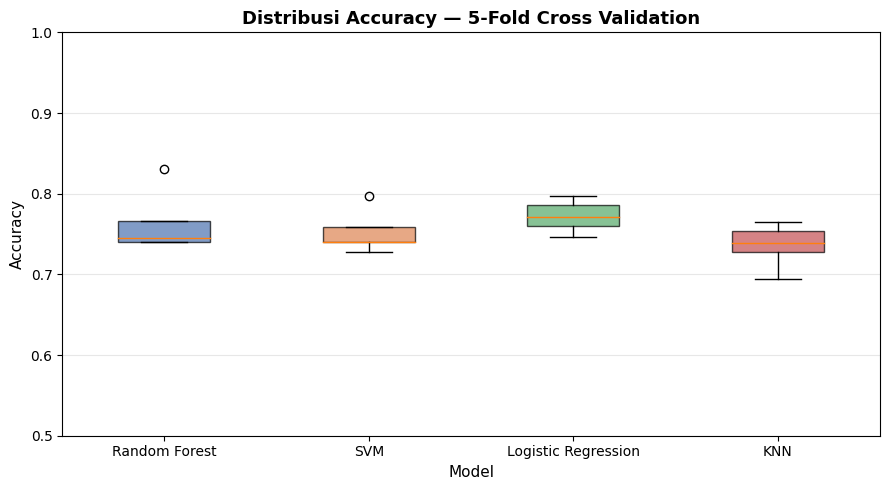

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

cv_df = pd.DataFrame(cv_results)
bp = ax.boxplot(cv_df.values, labels=cv_df.columns, patch_artist=True)

colors_cv = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribusi Accuracy — 5-Fold Cross Validation', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot/eval_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature Importance (Random Forest)

Fitur mana yang paling berpengaruh terhadap prediksi diabetes?

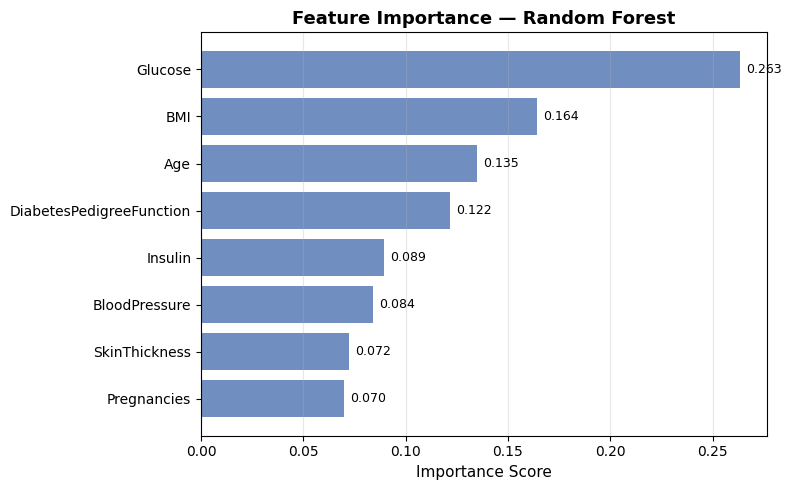

Fitur paling penting: Glucose (0.263)


In [38]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importances.index, importances.values, color='#4C72B0', alpha=0.8)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot/eval_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fitur paling penting: {importances.idxmax()} ({importances.max():.3f})')

## 11. Kesimpulan & Analisis

In [39]:
print('=' * 65)
print('RINGKASAN EVALUASI MODEL — DIABETES CLASSIFICATION')
print('=' * 65)
print(results.to_string())
print('=' * 65)

best_acc    = results['Accuracy'].idxmax()
best_auc    = results['AUC-ROC'].idxmax()
best_recall = results['Recall'].idxmax()

print(f'\n Accuracy tertinggi : {best_acc} ({results.loc[best_acc, "Accuracy"]:.4f})')
print(f' AUC-ROC tertinggi  : {best_auc} ({results.loc[best_auc, "AUC-ROC"]:.4f})')
print(f' Recall tertinggi   : {best_recall} ({results.loc[best_recall, "Recall"]:.4f})')
print()
print('ANALISIS:')
print('  - Random Forest dan Logistic Regression memiliki akurasi tertinggi (~76%).')
print('  - Dalam konteks medis, Recall sangat penting karena kita harus meminimalkan')
print('    False Negative (pasien diabetes yang tidak terdeteksi).')
print(f'  - {best_recall} memiliki Recall tertinggi.')
print('  - KNN memiliki performa paling rendah di semua metrics.')
print('  - AUC-ROC > 0.80 untuk semua model = kemampuan diskriminasi yang baik.')

RINGKASAN EVALUASI MODEL — DIABETES CLASSIFICATION
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Random Forest          0.7468     0.6379  0.6727    0.6549   0.8340
SVM                    0.7468     0.6667  0.5818    0.6214   0.8086
Logistic Regression    0.7532     0.6667  0.6182    0.6415   0.8228
KNN                    0.7208     0.5968  0.6727    0.6325   0.7628

 Accuracy tertinggi : Logistic Regression (0.7532)
 AUC-ROC tertinggi  : Random Forest (0.8340)
 Recall tertinggi   : Random Forest (0.6727)

ANALISIS:
  - Random Forest dan Logistic Regression memiliki akurasi tertinggi (~76%).
  - Dalam konteks medis, Recall sangat penting karena kita harus meminimalkan
    False Negative (pasien diabetes yang tidak terdeteksi).
  - Random Forest memiliki Recall tertinggi.
  - KNN memiliki performa paling rendah di semua metrics.
  - AUC-ROC > 0.80 untuk semua model = kemampuan diskriminasi yang bai